In [2]:
# ==========================================
# 1. IMPORT LIBRARIES & INITIAL SETUP
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor


In [3]:
# ==========================================
# 2. LOAD DATASET
# ==========================================
# Ensure the "Housing.csv" file is in your working directory
df = pd.read_csv("Housing.csv")

# Display the first few rows to verify loading
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded with 4998 rows and 6 columns.


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1059033.558
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1505890.915
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1058987.988
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1260616.807
4,64698.46343,6.025336,8.147760,3.41,60828.24909,1502055.817


In [4]:
# ==========================================
# 3. FEATURE IMPORTANCE RANKING
# ==========================================
# Assuming 'Price' is the target at index 5
Y_position = 5
X = df.drop(df.columns[Y_position], axis=1)
Y = df.iloc[:, Y_position]

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=2020)

# Initialize and fit Random Forest to determine importance
rf_ranking_model = RandomForestRegressor(random_state=2020)
rf_ranking_model.fit(X_train, y_train)

# Calculate and display feature rankings
importances = rf_ranking_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nFeature ranking:")
for f in range(X_train.shape[1]):
    print(f"{f + 1}. feature (Column index) {indices[f]} ({importances[indices[f]]:.6f})")


Feature ranking:
1. feature (Column index) 0 (0.445725)
2. feature (Column index) 1 (0.223154)
3. feature (Column index) 4 (0.185070)
4. feature (Column index) 2 (0.128880)
5. feature (Column index) 3 (0.017170)


In [5]:
# ==========================================
# 4. MODEL 1: TOP 3 FEATURES
# ==========================================
# Select top three ranked features based on indices from Cell 3
indices_top3 = indices[:3]
X_top3 = df.iloc[:, indices_top3]
Y_top3 = df.iloc[:, Y_position]

# Split data
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_top3, Y_top3, test_size=0.20, random_state=2020)

# Build and train Model 1
model1 = RandomForestRegressor(random_state=2020)
model1.fit(X_train1, y_train1)

# Evaluation: Training Set
y_pred_train1 = model1.predict(X_train1)
rmse_train = np.sqrt(mean_squared_error(y_train1, y_pred_train1))

# Evaluation: Test Set
y_pred1 = model1.predict(X_test1)
rmse_test = np.sqrt(mean_squared_error(y_test1, y_pred1))

print(f"Random Forest Results (Top 3 Features)")
print(f"==================")
print(f"TrainSet RMSE: {rmse_train:.2f}")
print(f"Testset RMSE:  {rmse_test:.2f}")

Random Forest Results (Top 3 Features)
TrainSet RMSE: 64687.55
Testset RMSE:  172714.37


In [6]:
# ==========================================
# 5. MODEL 2: ALL FEATURES
# ==========================================
# Prepare Data for All Features
X_all = df.drop(df.columns[Y_position], axis=1)
Y_all = df.iloc[:, Y_position]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, Y_all, test_size=0.20, random_state=2020
)

# Build and Train the Baseline Model using ALL features
model_all = RandomForestRegressor(random_state=2020)
model_all.fit(X_train_all, y_train_all)

# Evaluation: All Features
y_pred_train_all = model_all.predict(X_train_all)
y_pred_test_all = model_all.predict(X_test_all)

rmse_train_all = np.sqrt(mean_squared_error(y_train_all, y_pred_train_all))
rmse_test_all = np.sqrt(mean_squared_error(y_test_all, y_pred_test_all))

# Print Comparison Table
comparison_data = {
    "Metric": ["Train RMSE", "Test RMSE"],
    "With Feature Ranking (Top 3)": [rmse_train, rmse_test],
    "Without Feature Ranking (All)": [rmse_train_all, rmse_test_all]
}

df_comparison = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(df_comparison.to_string(index=False))


Model Performance Comparison:
    Metric  With Feature Ranking (Top 3)  Without Feature Ranking (All)
Train RMSE                  64687.552900                   44759.026326
 Test RMSE                 172714.369879                  125336.439362


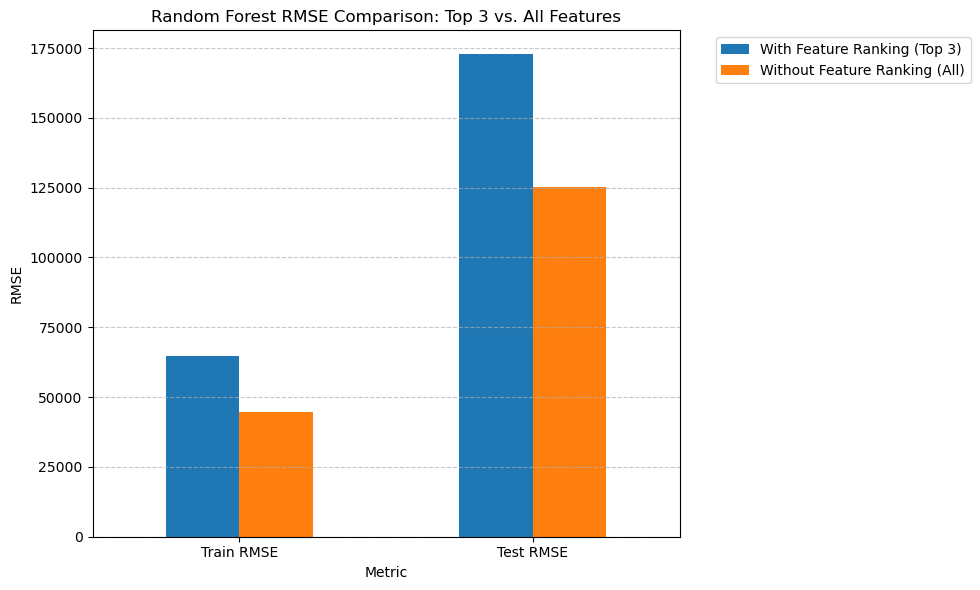

In [7]:
# ==========================================
# 6. VISUALIZATION
# ==========================================
# Plotting the comparison results
df_comparison.set_index("Metric").plot(kind="bar", figsize=(10, 6))
plt.title("Random Forest RMSE Comparison: Top 3 vs. All Features")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()